## Abstract
In this project, we developed a structured database and web application to explore and analyze Housing Development Board (HDB) resale flat prices in Singapore. Using data from data.gov.sg [2], specifically from January 2017 onward, we focused on tracking key housing trends such as average resale prices by flat type, town, storey range, and lease commencement year. We chose this date range because it aligns with the government's newer housing policies and ensures that our analysis is based on more recent and relevant transactions. By transforming the raw CSV dataset into a normalized relational database, we were able to efficiently run SQL queries that answer specific research questions. These insights are presented through a user-friendly web interface built with Node.js, Express [8], MySQL, and EJS. Our work highlights how database design and backend development can be used together to support deeper understanding of housing affordability and pricing patterns in Singapore.

## Introduction
HDB flats play a central role in Singapore’s housing landscape, making up the majority of homes for citizens. With rising interest in housing affordability and resale pricing trends, there is increasing value in exploring the resale flat market through structured data analysis. For this project, we chose to work with the HDB Resale Flat Prices dataset available on data.gov.sg [2], focusing on data starting from January 2017. This time frame was selected because it reflects more current market dynamics and housing policy changes, ensuring that our insights remain relevant to today’s context.

We began by building a relational database to model the data, which includes details such as town, block, flat type, floor area, lease commencement year, storey range, and resale price. Using SQL and normalization techniques, we organized the dataset into efficient tables representing towns, blocks, flats, and transactions. To make the analysis interactive and user-friendly, we developed a web application that lets users explore various queries visually, such as identifying towns with the highest resale prices or understanding how lease year affects flat value.

This report documents our process from dataset selection and database modeling to implementation and query visualization. Through this project, we aim to show how structured data and web development tools can be combined to support meaningful housing data exploration in a local context.


## Stage 1: Dataset Selection and Critique
---
This report explores the HDB Resale Flat Prices dataset, available on Singapore’s [data.gov.sg](https://data.gov.sg/dataset/resale-flat-prices) [1]. The dataset captures monthly transactions of resale flats, providing key details such as town, flat type, floor area, lease start date, and resale price. Its structured format makes it ideal for building a relational model and examining long-term housing trends in Singapore.

### Dataset Source and Accessibility

The dataset is maintained by the Housing & Development Board (HDB) and hosted on the government’s official open data portal, data.gov.sg [1]. It is published under the Singapore Open Data Licence v1.0 [2], which allows the data to be freely used, shared, and modified, making it accessible for both public and academic use.

- **Credibility**: The data comes from a trusted government source.  
- **Accessibility**: It’s downloadable in CSV format, and metadata is clearly provided.  
- **License**: The licence is flexible and encourages educational use.

### Quality and Detail

This dataset provides comprehensive information for each resale transaction. It includes:

- Town and block information  
- Type of flat and size in square meters  
- Storey range and lease commencement year  
- Final resale price  

These attributes offer rich possibilities for structured storage and querying using SQL.

- **Potential Limitation**: The dataset doesn’t contain details like buyer or seller demographics, or whether the flat has been renovated which are factors that might also affect pricing.

- **Scope Note**: It’s worth noting that this dataset only covers resale flats, not new sales or rental transactions.

### Documentation and Use

The documentation provided is clear enough for users to understand each column, and the dataset has seen widespread use in government planning, academic research, and data visualizations [1].

- **Strengths**: Great for tracking price trends, comparing towns, and performing data analysis across time.  
- **Improvement Area**: A bit more detail in the documentation, like how storey ranges are defined, could help users interpret the data more precisely.

### Interrelation and Discoverability

The way the data is structured allows it to be easily connected to other datasets, such as:

- Town or region-level population data  
- Income or employment statistics  
- Public transport accessibility data  

**Future Potential**: Linking this with other datasets could lead to deeper insights about how location and accessibility affect housing affordability.

### Interest and Research Questions

Housing is a topic that affects almost everyone in Singapore, so it’s no surprise that this dataset is both timely and relevant. It gives a data-backed way to explore how flat prices vary across time, locations, and flat types.

#### Research Questions

1. Which towns have the highest average resale price for 4-room flats?  
2. How have resale prices changed over time across different flat types?  
3. Is there a correlation between lease commencement year and resale value?  
4. Do higher-floor flats consistently command higher prices?  
5. Which flat types are most frequently transacted in each town?

These are the kinds of questions that benefit from being explored with a relational database, rather than a basic spreadsheet. A database lets us organize and query the data in more powerful and scalable ways.



## Stage 2: Model Your Data

This section explains the data modeling process used for the HDB resale flat price dataset. It begins with the design of an Entity Relationship diagram, which is later converted into a relational schema. This approach helps ensure that the structure of the database is both logical and efficient. The design follows best practices covered in the module materials and class discussions [1].

---

### Entity-Relationship Diagram

The Entity Relationship diagram provides a clear overview of the key elements in the dataset, which include towns, blocks, flats, and transactions, along with the relationships between them. These entities and their attributes are based on the structure of the HDB resale flat dataset. To accurately reflect how they are connected, cardinality is used to represent one to many relationships across different layers of housing data, including locations, individual flats, and their corresponding resale records [2].

To better understand how this model works in the real world, consider the town of Bishan in Singapore. Bishan includes several HDB blocks, such as Block 101. Within this block, there may be multiple flats, like unit #12-123, which might have been sold once in 2015 and again in 2022. In this case, Bishan is the town, Block 101 is the block, unit #12-123 is the flat, and each sale is recorded as a separate transaction. This example clearly demonstrates the one-to-many structure of the data, where a town can include many blocks, a block can contain many flats, and a flat can be linked to multiple transactions over time.

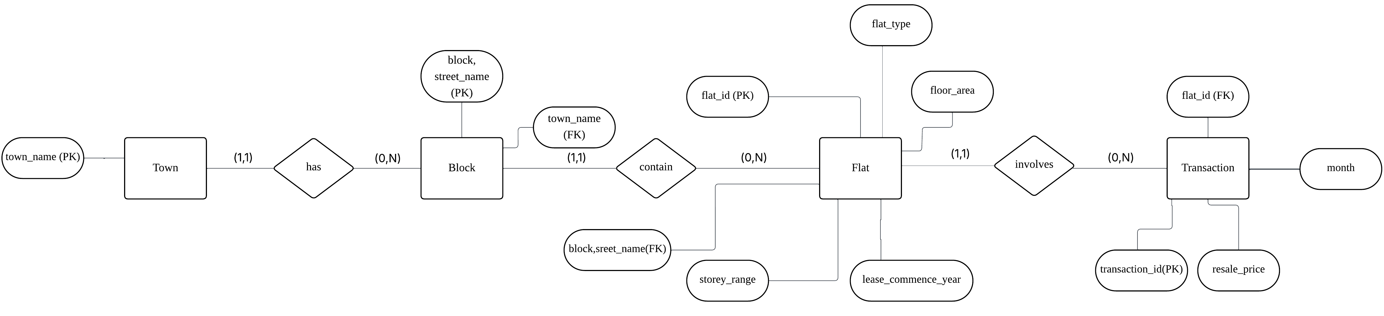

**ER Diagram Creation**:  

This Entity Relationship diagram outlines four main entities: Town, Block, Flat, and Transaction. Each one includes its own set of attributes and a designated primary key. The connections between these entities follow the standard notation taught in this module [1]. To clearly show how they relate, formal cardinality is used. For example, a Town may be linked to zero or many Blocks, while each Block is connected to exactly one Town. This structure helps maintain accuracy in how the data is organised and makes it easier to run consistent and meaningful queries across the database.

The diagram also reflects real-life structure and relationships within the HDB resale data. For instance, a Town can have many Blocks, but each Block belongs to one specific Town. Similarly, a Block can contain many Flats, but each Flat belongs to exactly one Block. Each Flat can be involved in multiple Transactions, representing its resale history over time, while each Transaction relates to one specific Flat. These one-to-many relationships are important for maintaining data integrity and supporting complex queries, such as tracking resale trends across different towns or identifying flats with multiple transactions.

**Attributes and Relationships**:

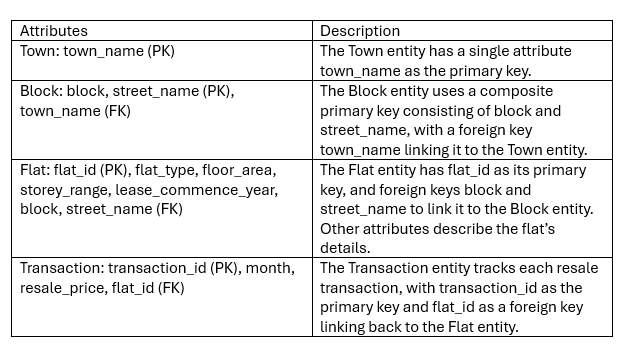




### Relational Schema

The Entity-Relationship diagram has been transformed into a relational schema that clearly shows how the data will be stored in a relational database. This schema lists the tables, their attributes, and how they are connected using primary and foreign keys. This design helps keep the data accurate, allows for efficient searches, and makes managing the HDB resale flat data straightforward.

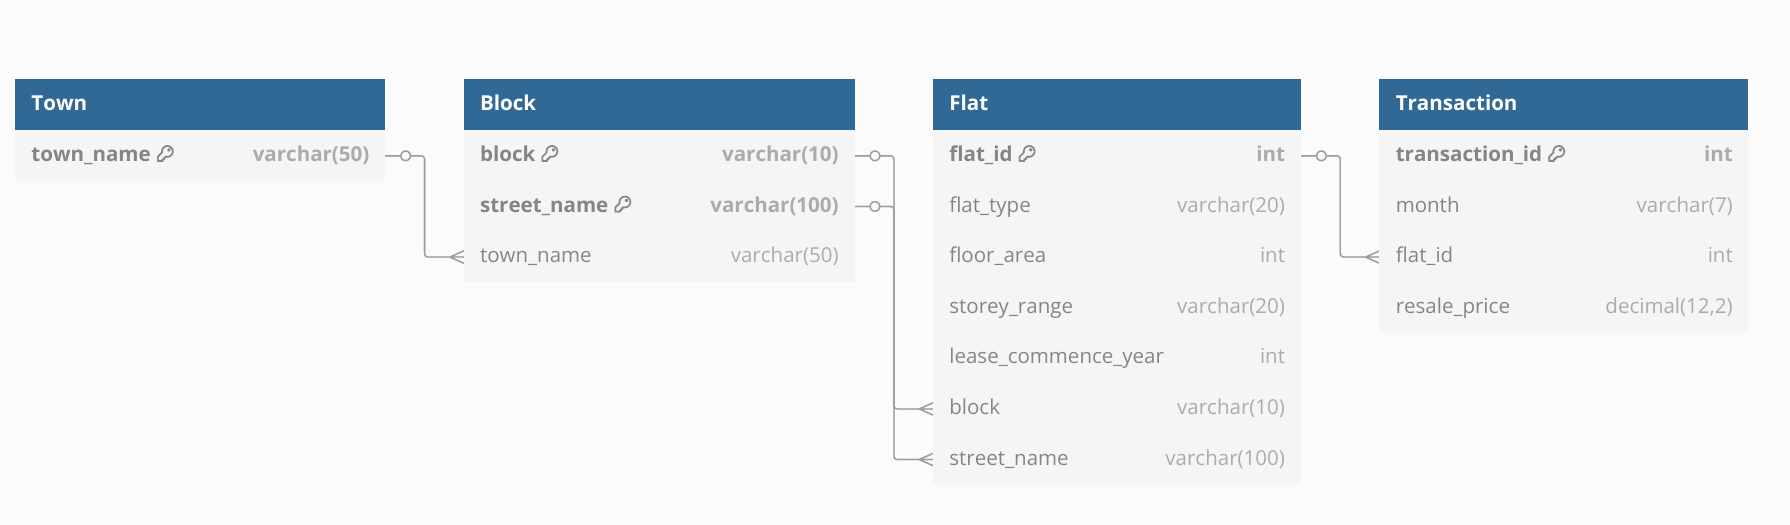

**Schema Translation:**  
The E/R diagram has been turned into four related tables: Town, Block, Flat, and Transaction. Each table has a unique ID to keep track of its records, and foreign keys link the tables together so everything stays connected and consistent.

**Tables Description:**  

- **Town:** Uses the town’s name (town_name) as its unique ID to store each town’s name.

- **Block:** Has a combined ID made up of block and street_name. It also includes town_name to show which town each block belongs to.

- **Flat:** Has a unique ID called flat_id and keeps details like the flat type, floor area, storey range, and when the lease started. It also links to the block and street it belongs to using block and street_name.

- **Transaction:** Has a unique ID called transaction_id and records when the transaction happened (month), the resale price, and which flat was sold (flat_id).

**Referential Integrity:**  
The foreign keys make sure everything is connected properly: blocks link to towns, flats link to blocks, and transactions link to flats. This helps keep the data accurate and makes it easy to ask complex questions that need information from multiple tables.

### Database Normalization and Analysis
Normalization is an important step to organize the HDB resale flat price database so the data is clear and free of errors. By following normalization rules, we reduce repeated data and avoid mistakes. This is especially important because the data has many connected parts like towns, blocks, flats, and resale transactions [4].

We checked our database design using the first three normal forms called 1NF, 2NF, and 3NF to make sure it stores data properly and allows easy searching. We also confirmed it follows Boyce-Codd Normal Form or BCNF to ensure the design is strong and reliable [5].

- First Normal Form means each table stores simple, separate pieces of data. For example, each transaction shows only one resale event and does not mix many values in one field [6].

- Second Normal Form means all information depends fully on the main key. Since each table has one main key, details like flat type or floor size depend only on that flat’s ID [4].

- Third Normal Form means there are no hidden links between other data fields. For example, the lease start year or storey range depends only on the flat’s ID and not on other fields [5].

Our design also follows BCNF which means all data depends on keys that uniquely identify each record. This helps avoid duplicate data and problems when updating information [4].

Choosing BCNF strikes a good balance by keeping data clean while still making searching easy. Since our data mainly tracks resale transactions without complex multiple values, going beyond BCNF was not necessary.

In summary, normalization helps make the database reliable by reducing repeated data like not storing the same town or block details many times. It also ensures updates such as price changes are applied correctly everywhere. This clear and tidy design makes it easier to study resale trends and housing patterns across towns and flats [7].


### Functional Dependencies in the HDB Resale Flat Database

Functional dependencies explain how different pieces of data in the database relate to each other. Understanding these relationships helps keep the database organized and accurate.

Here are the main functional dependencies:

- The town’s name uniquely identifies each town.

- The block and street name together uniquely identify each block, and each block belongs to one town.

- Each flat has a unique ID that determines all details about the flat, such as its type, floor area, storey range, lease start year, and the block and street it belongs to.

- Each transaction has a unique ID that identifies details like when the transaction happened, the resale price, and which flat was sold.

These dependencies show that all information depends fully on the main keys, without partial or hidden dependencies. This means the database follows the third normal form, which helps avoid mistakes and keeps the data consistent.

### Why	Functional	Dependencies	Matter	for	Normalization
These	dependencies	show	that	all	non-key	fields	depend	fully	on	their	primary	key,	with	no	partial	or	hidden	dependencies	between	non key	fields.	This	confirms	that	the	database	design	meets	the	requirements	of	the	Third	Normal	Form	(3NF),	helping	to	ensure	data consistency	and	avoid	redundancy [5].

## Stage 3. Create the database 
---

Stage 3 involves the implementation of the database schema. This includes dropping any existing versions, creating normalized tables for the key entities, establishing referential integrity, and loading raw data into a staging table. These steps form the backbone for accurate and efficient data storage and retrieval. After building the database, we use SQL queries to dig into the data and find answers to key research questions. This helps us understand resale prices, how they change over time, and what factors affect them.

### Drop and create the database
We will be using hdb_resale as my main database. In this stage, we set up the database that will store all the data for the project. First, we remove any existing database named hdb_resale to ensure a clean start. Then, we create a new database called hdb_resale and switch to it, so that all following operations will be done within this database.



In [ ]:
DROP DATABASE IF EXISTS hdb_resale;
CREATE DATABASE hdb_resale;
USE hdb_resale;

After that, we create a new database user named root with a password, giving this user permission to access and modify everything inside the hdb_resale database. This helps control who can work with the database and keeps things secure.

In [ ]:
DROP USER IF EXISTS 'root'@'%';
CREATE USER 'root'@'%' IDENTIFIED BY 'T0123667e-';

GRANT ALL ON hdb_resale.* TO 'root'@'%';



### Create the normalized tables

To keep the resale flat data neat and easy to work with, we broke it down into several smaller tables. This helps avoid repeating the same info and makes sure everything stays accurate. We set up tables for:

- Towns: Just the unique town names.
- Blocks: Different blocks within each town, identified by block number and street name.
- Flats: Details about each flat, linked to its block.
- Transactions: Records of each resale, showing when it happened and for how much, connected to the right flat.

Below are the commands we used to create these tables and set up the relationships between them, so the data all fits together properly.

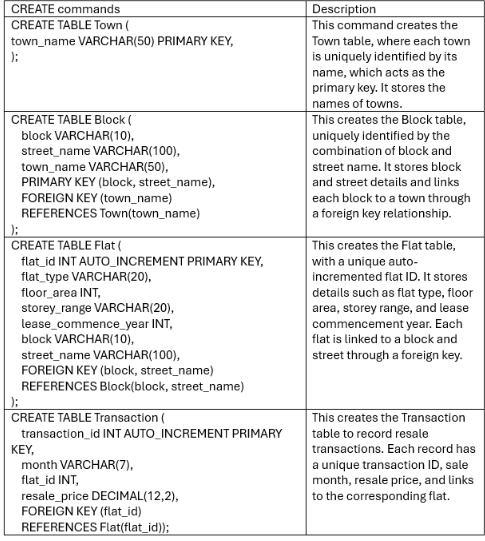

### Create the staging table to load raw CSV data

Before transferring data into the normalized tables, a temporary staging table named raw_resale_data was created to hold the raw information imported from the CSV file. This table uses appropriate data types to match the nature of each field, for example, the month is stored as a VARCHAR(7) to accommodate the "YYYY-MM" format, and resale_price uses a DECIMAL(12,2) type to precisely represent currency values. This staging area allows us to efficiently validate, clean, and preprocess the data before organizing it into the structured, normalized tables for more effective analysis and querying.


In [ ]:
CREATE TABLE raw_resale_data (
    month VARCHAR(7),
    town VARCHAR(50),
    flat_type VARCHAR(20),
    block VARCHAR(10),
    street_name VARCHAR(100),
    storey_range VARCHAR(20),
    floor_area INT,
    flat_model VARCHAR(50),
    lease_commence_year INT,
    resale_price DECIMAL(12,2)
);


### Load CSV data into the staging table

Next, we loaded the resale flat data into a temporary staging table. This raw data comes from a CSV file containing resale transactions from January 2017 up to the present day. Using this staging table allows us to efficiently import and review the data before organizing it into the normalized tables.

The command below shows how we imported the CSV file into the raw_resale_data staging table, specifying how the fields and lines are separated, and skipping the header row:

In [ ]:
## Coursera Lab version (use this one on Coursera platform)
LOAD DATA LOCAL INFILE '/home/coder/project/jolin database hdb mids/hdb_database/resale.csv'
INTO TABLE raw_resale_data
FIELDS TERMINATED BY ','
ENCLOSED BY '"'
LINES TERMINATED BY '\n'
IGNORE 1 ROWS;

## Local machine version (use this one on your own Windows PC)
LOAD DATA LOCAL INFILE 'C:\\Users\\jolin\\Downloads\\ResaleFlatPrices\\Resale flat prices based on registration date from Jan-2017 onwards.csv' 
INTO TABLE raw_resale_data
FIELDS TERMINATED BY ','
ENCLOSED BY '"'
LINES TERMINATED BY '\r\n'
IGNORE 1 ROWS;

In [ ]:
 SELECT * FROM raw_resale_data LIMIT 10;

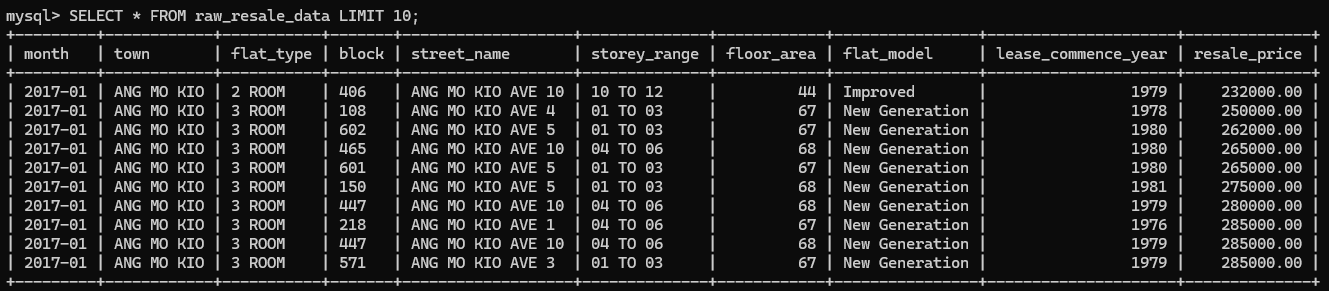


### Database Table Creation Commands and Descriptions

After creating the normalized tables, we populated them with data extracted from the staging table. This step organizes the raw resale flat data into structured tables by inserting unique records to avoid duplication.

#### Insert distinct towns into Town table

We insert all unique town names from the raw data into the Town table.

In [ ]:
INSERT IGNORE INTO Town (town_name)
SELECT DISTINCT town
FROM raw_resale_data;

#### Insert distinct blocks into Block table

 Next, we insert distinct block and street name combinations along with their associated town into the Block table.

In [ ]:
INSERT IGNORE INTO Block (block, street_name, town_name)
SELECT DISTINCT block, street_name, town
FROM raw_resale_data;

#### Insert distinct flats into Flat table

We then populate the Flat table with unique flats, including details such as flat type, floor area, storey range, lease commencement year, and location (block and street).

In [ ]:
INSERT IGNORE INTO Flat (flat_type, floor_area, storey_range, lease_commence_year, block, street_name)
SELECT DISTINCT flat_type, floor_area, storey_range, lease_commence_year, block, street_name
FROM raw_resale_data;

#### Insert transactions into Transaction table

Finally, the resale transactions are inserted into the Transaction table. We link each transaction to the corresponding flat using the flat ID. This involves joining the staging table with the Flat table based on multiple matching attributes.

In [ ]:
INSERT IGNORE INTO Transaction (month, flat_id, resale_price)
SELECT
    month,
    f.flat_id,
    resale_price
FROM raw_resale_data r
JOIN Flat f ON r.flat_type = f.flat_type
    AND r.floor_area = f.floor_area
    AND r.storey_range = f.storey_range
    AND r.lease_commence_year = f.lease_commence_year
    AND r.block = f.block
    AND r.street_name = f.street_name;


#### Verifying data in the normalized Tables

After inserting the data into the normalized tables, we verified that the data was correctly populated by selecting a sample of records from each table. This step helps confirm the integrity of the data before proceeding with any analysis or further processing.

In [ ]:
SELECT * FROM Town LIMIT 5;
SELECT * FROM Block LIMIT 5;
SELECT * FROM Flat LIMIT 5;
SELECT * FROM Transaction LIMIT 5;


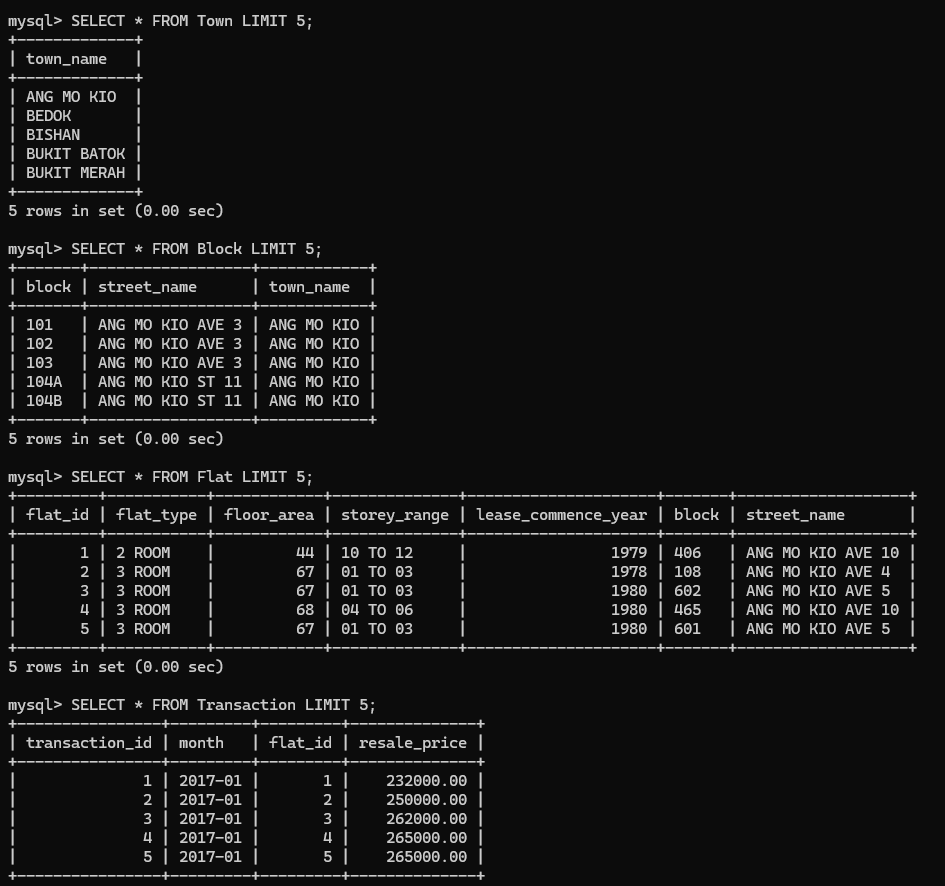

### Reflection on Database Implementation

My database accurately represents the original HDB resale data. By organizing the data into clear tables for towns, blocks, flats, and transactions, I kept things neat and avoided repeating information. Using a staging table helped me import the raw data smoothly before breaking it down into these tables.

I made sure to match the data types closely to the real data, like storing prices as decimals and months as text in the year-month format, so nothing important gets lost or changed. Although I ran into some messy data and duplicates, the final setup captures the key details well and keeps the relationships clear.



### SQL Queries to Answer Research Questions

In this part, we use the implemented database to answer specific research questions related to HDB resale trends. We write and run SQL queries that analyze the data to reveal insights such as which towns have the highest average resale prices for certain flat types, how resale prices change over time, and other patterns related to lease commencement, floor levels, and transaction frequencies. By doing this, we aim to better understand the resale market dynamics using the structured data we prepared.

For most of the questions, we focus on the average resale price rather than individual sale prices. To ensure clarity and precision, the resale prices are formatted using FORMAT(ROUND(AVG(tr.resale_price), 2), 2) AS avg_resale_price. This means the average prices are rounded to two decimal places and displayed with consistent formatting.

Using the average resale price helps smooth out any extreme values or one-off sales, providing a clearer and more reliable picture of general market trends and typical pricing. This approach also makes it easier to compare resale prices across different towns, flat types, and time periods.


#### 1. Top 10 Towns with Highest Average Resale Price for 4-Room Flats 

This SQL query calculates the average resale price of 4-room flats for each town. It joins the Transaction, Flat, Block, and Town tables to link sales data with flat details and their locations. The query filters to include only flats labeled as "4 ROOM." Then, it groups the data by town name and calculates the average resale price for each town. The results are sorted from highest to lowest average price, showing the top ten towns.

In [ ]:
SELECT
    t.town_name,
    FORMAT(ROUND(AVG(tr.resale_price), 2), 2) AS avg_resale_price
FROM
    Transaction tr
JOIN Flat f ON tr.flat_id = f.flat_id
JOIN Block b ON f.block = b.block AND f.street_name = b.street_name
JOIN Town t ON b.town_name = t.town_name
WHERE
    f.flat_type = '4 ROOM'
GROUP BY
    t.town_name
ORDER BY
    AVG(tr.resale_price) DESC
LIMIT 10;


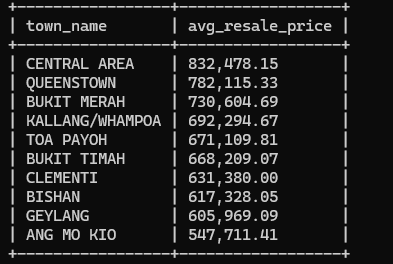

#### 2. Resale Price Trends Over Time by Flat Type

This query calculates the average resale prices for each flat type over the years. It groups the data by flat type and year, then finds the average resale price for each group. The year is taken from the month column and the prices are rounded to two decimal places to make them easier to read. The results are sorted by year and flat type so you can see how resale prices for different flat types, like one-room or executive flats, have changed from 2017 up to 2025.

In [ ]:
SELECT
  f.flat_type,
  CAST(LEFT(tr.month, 4) AS UNSIGNED) AS year,
  FORMAT(ROUND(AVG(tr.resale_price), 2), 2) AS avg_resale_price
FROM
  Transaction tr
JOIN
  Flat f ON tr.flat_id = f.flat_id
GROUP BY
  f.flat_type,
  year
ORDER BY
  year ASC,
  f.flat_type ASC;
;


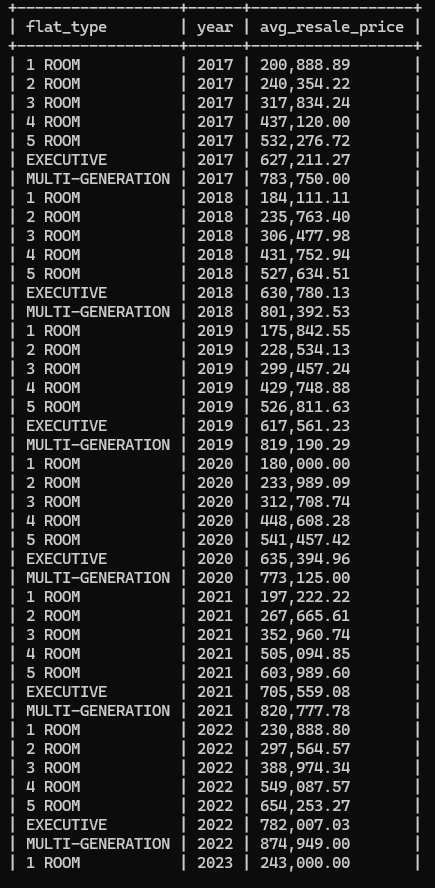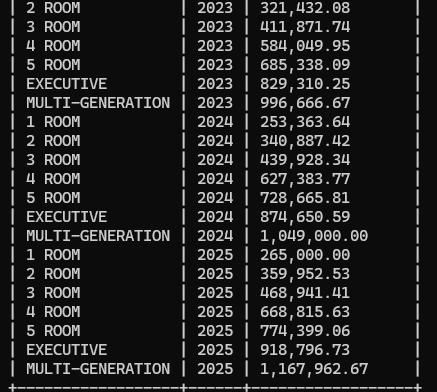

#### 3. Correlation Between Lease Commencement Year and Resale Value

This SQL query finds the average resale price of flats based on their lease commencement year. It joins the Flat table with the Transaction table to link resale prices to each flat's lease start year. The results are grouped by the lease commencement year and sorted in ascending order.

This helps us see how the age of a flat's lease correlates with its resale value. Generally, flats with newer leases tend to have higher average resale prices, reflecting the value impact of lease length.


In [ ]:
SELECT
    f.lease_commence_year,
    FORMAT(AVG(tr.resale_price), 2) AS avg_resale_price
FROM
    Flat f
JOIN
    Transaction tr ON f.flat_id = tr.flat_id
GROUP BY
    f.lease_commence_year
ORDER BY
    f.lease_commence_year;


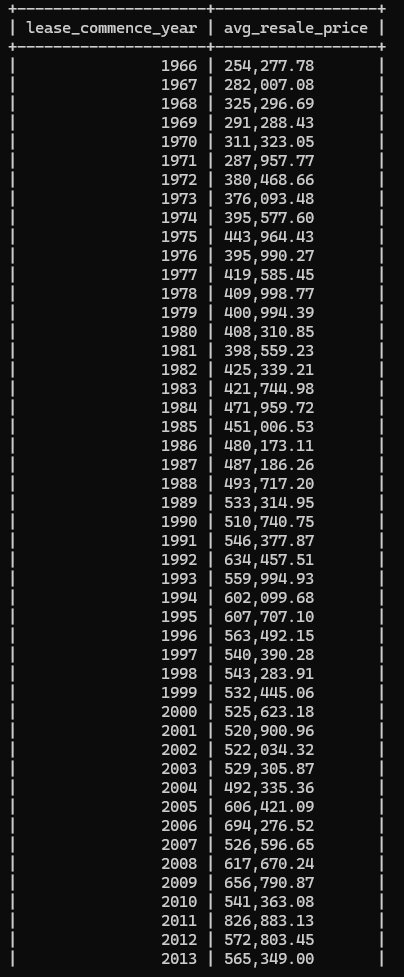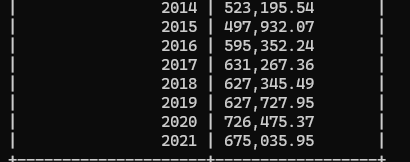

What it does:
This query calculates the average resale price of flats grouped by the year their lease started. It helps analyze if older or newer leases affect resale prices, showing trends based on lease commencement year.



#### 4. Do Higher Floors Command Higher Prices?

This SQL query investigates whether flats on higher floors generally have higher resale prices. It calculates the average resale price for flats grouped by their storey range, such as "01 TO 03", "04 TO 06", and so forth.

By joining the Flat and Transaction tables, the query links resale prices to their corresponding storey ranges. The results are ordered by storey range to reveal how average resale prices vary as you move from lower to higher floors.

From the data, you can observe a clear trend: average resale prices tend to increase as the storey range rises, with prices starting around $466,216 for floors 1 to 3 and reaching over $1,200,000 for floors 49 to 51. This suggests that flats on higher floors command a significant price premium, likely due to factors such as better views, reduced noise, and increased privacy.

However, it is worth noting that the price increase is not strictly linear, and the highest floors might also be influenced by other considerations such as building design or accessibility. Overall, the trend indicates that higher floors are more valued in the resale market.

In [ ]:
SELECT
    f.storey_range,
    FORMAT(AVG(tr.resale_price), 2) AS avg_resale_price
FROM
    Flat f
JOIN
    Transaction tr ON f.flat_id = tr.flat_id
GROUP BY
    f.storey_range
ORDER BY
    f.storey_range;


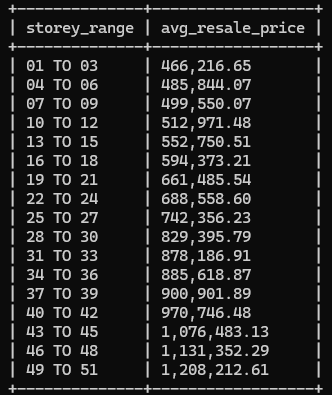

#### 5. Most Frequently Transacted Flat Types in Each Town

This query finds the most frequently transacted flat types in each town. It joins the Town, Block, Flat, and Transaction tables to count how many resale transactions occurred for each flat type in each town. The results are grouped by town and flat type, and ordered by transaction count in descending order.

You can see, for example, that in ANG MO KIO, 3-room flats had the highest number of transactions, followed by 4-room flats and then 5-room flats. This helps identify which flat types are most popular in terms of resale activity across different towns.

In [ ]:
SELECT
    t.town_name,
    f.flat_type,
    COUNT(*) AS transaction_count
FROM
    Town t
JOIN
    Block b ON t.town_name = b.town_name
JOIN
    Flat f ON b.block = f.block AND b.street_name = f.street_name
JOIN
    Transaction tr ON f.flat_id = tr.flat_id
GROUP BY
    t.town_name,
    f.flat_type
ORDER BY
    t.town_name,
    transaction_count DESC;



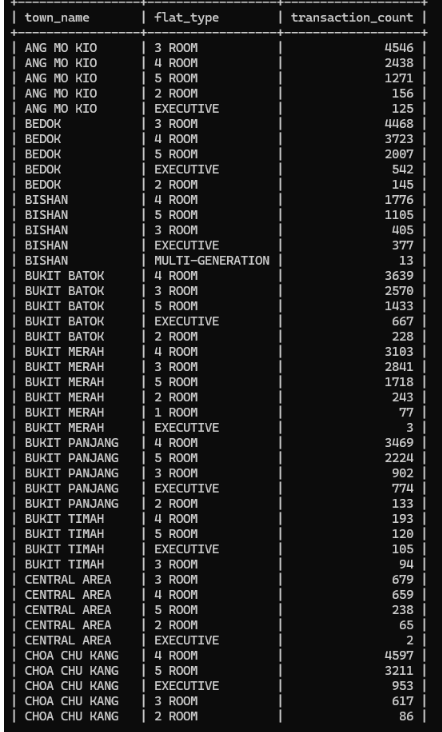
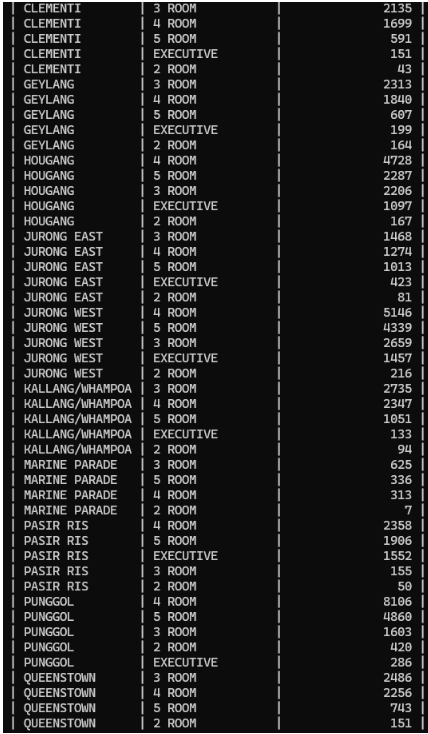
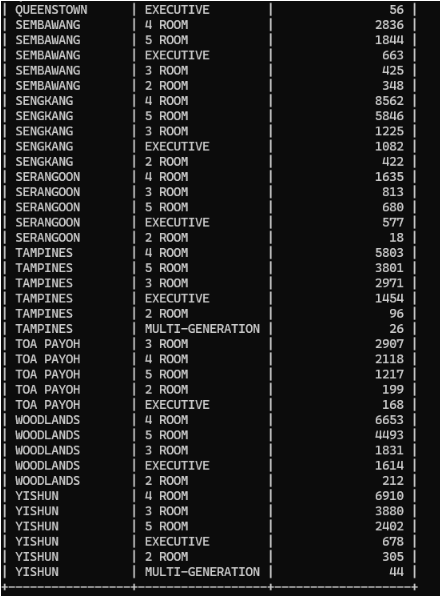

## Stage 4: Making the website
---


### Web Application Setup Using Node.js and Express
To help answer our research questions, we built a web application using Node.js and the Express framework. This app connects to our MySQL database (hdb_resale) using a connection pool, which improves performance by handling multiple database requests at the same time. The server runs on port 3001 and uses EJS templates to generate dynamic pages based on the data retrieved from the database [8].

### Database Access Configuration
To make this connection possible, we created a MySQL user named 'root' with the password 'T0123667e-', and gave it full access to the hdb_resale database using the GRANT ALL command. This ensures that our backend has the necessary permissions to run all the required queries smoothly and securely [9].




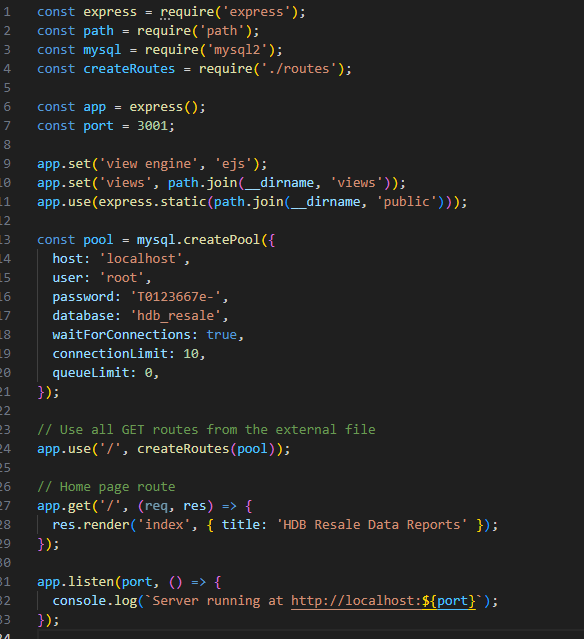

### Modular Project Structure
For better organization and easier maintenance, we structured our code into separate parts. The main application logic is handled in app.js, while all the route definitions are kept in a separate file (routes.js). This file is responsible for handling each query and sending the results to the correct EJS template. We also organized our front-end files inside a views/ folder, where index.ejs serves as the homepage and qn1.ejs to qn5.ejs each display the results for different queries.

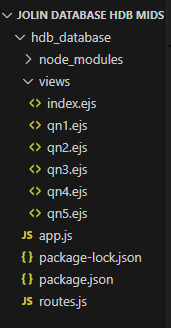

## Data Query Results
When users first access the web application, they are are presented with a clean and intuitive homepage.This page acts as a central menu where users can choose from five different data reports related to HDB resale prices.

The homepage is rendered through the following route in app.js:

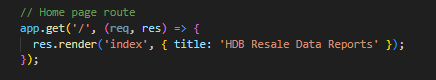

Below is the final layout of the homepage as it appears to users when the application runs.


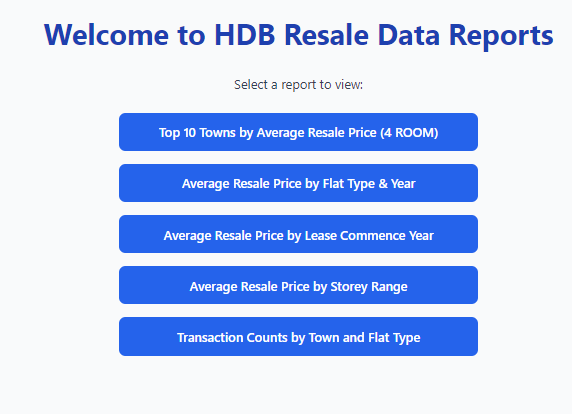


We start with our first query, which focuses on identifying the top 10 towns in Singapore with the highest average resale prices for 4-room HDB flats. This begins with the /top-towns route defined in our backend. Inside that route, we wrote a SQL query that brings together data from several related tables: Transaction, Flat, Block, and Town.

The query looks for flats specifically labeled as "4 ROOM" and calculates the average resale price for each town. It then sorts the towns from highest to lowest based on those average prices and limits the output to just the top 10 results.
 

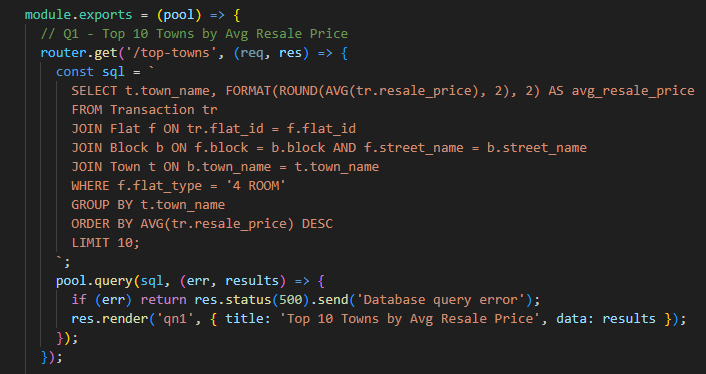



Once the data is retrieved, it’s passed into the qn1.ejs view file, where it’s displayed neatly in a table. On the page, users can clearly see each town’s name along with its corresponding average resale price.

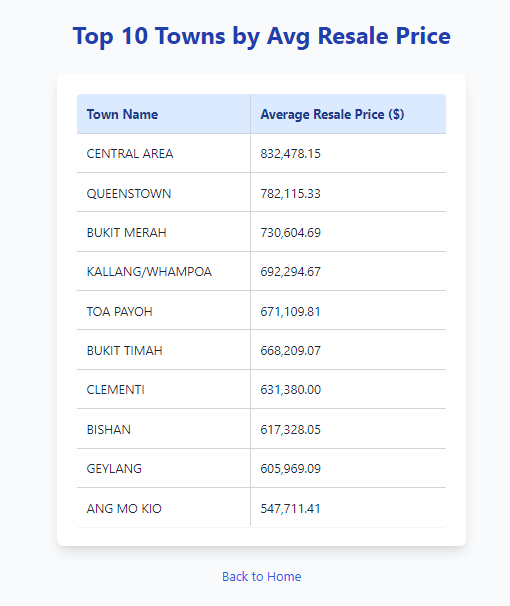

The next query looks at how average resale prices change across different flat types and years. In the backend, we created a route called /avg-price-by-year. Inside that route, we wrote a SQL query that groups the data by both flat type and year. To extract the year from the month column, we used the LEFT function to grab the first four characters and cast it as an integer. The query then calculates the average resale price for each flat type in each year and sorts the results in ascending order.


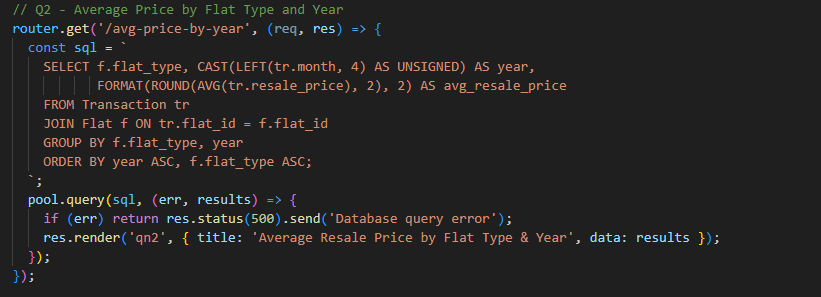


Once the results are retrieved, they're passed to the qn2.ejs template, where the data is displayed in a table. At the top of the page, users can choose a specific year using the filter buttons. When a year is selected, the page shows all the flat types and their corresponding average resale prices for that year. This makes it easy for users to compare pricing trends across different flat types and observe how resale values have shifted over time. 

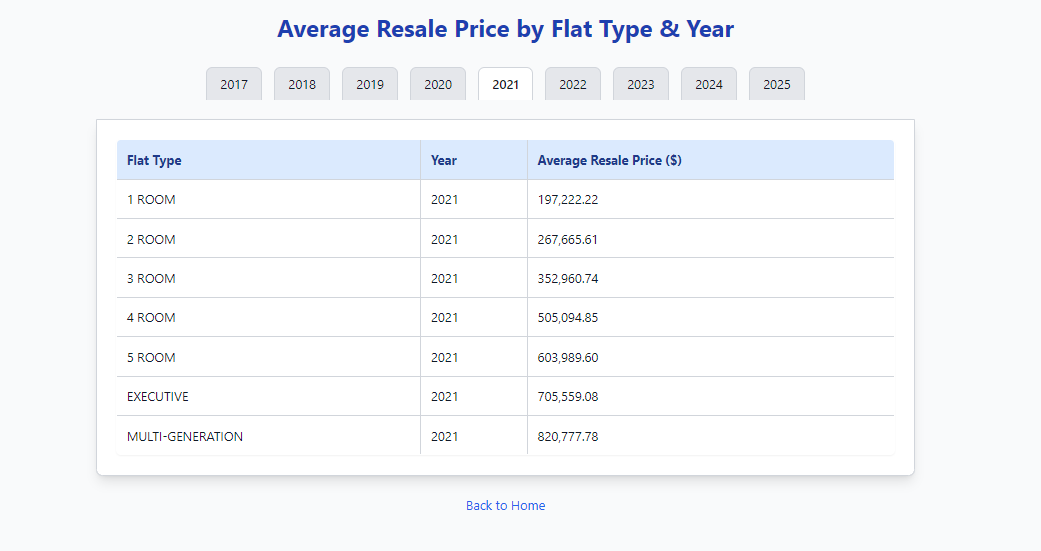

This part of the application focuses on showing the average resale prices based on the lease commencement year of HDB flats. In the /lease-year-avg-price route, we wrote a SQL query that groups the data by each flat’s lease commencement year. It calculates the average resale price for each year using the AVG() function, and formats the results to two decimal places for readability.

The data is pulled from the Flat and Transaction tables, joined by the flat_id, and sorted by lease year in ascending order. This helps users clearly see how resale prices vary depending on how old the flat is, starting from as early as the 1960s.

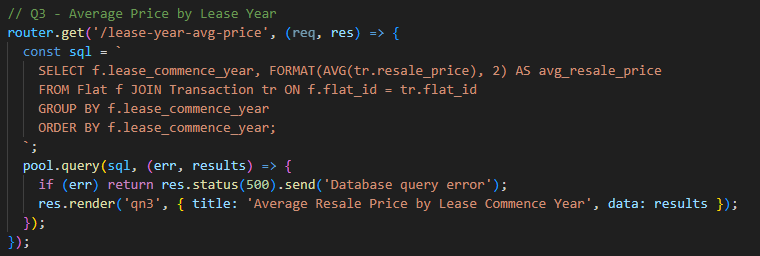

The query results are sent to the qn3.ejs file, where the front end displays the data in a clean two-column table: one for the lease year and one for the average resale price. This view gives users an easy way to observe pricing trends over time, which can be useful for understanding how the age of a flat influences its value in the resale market.

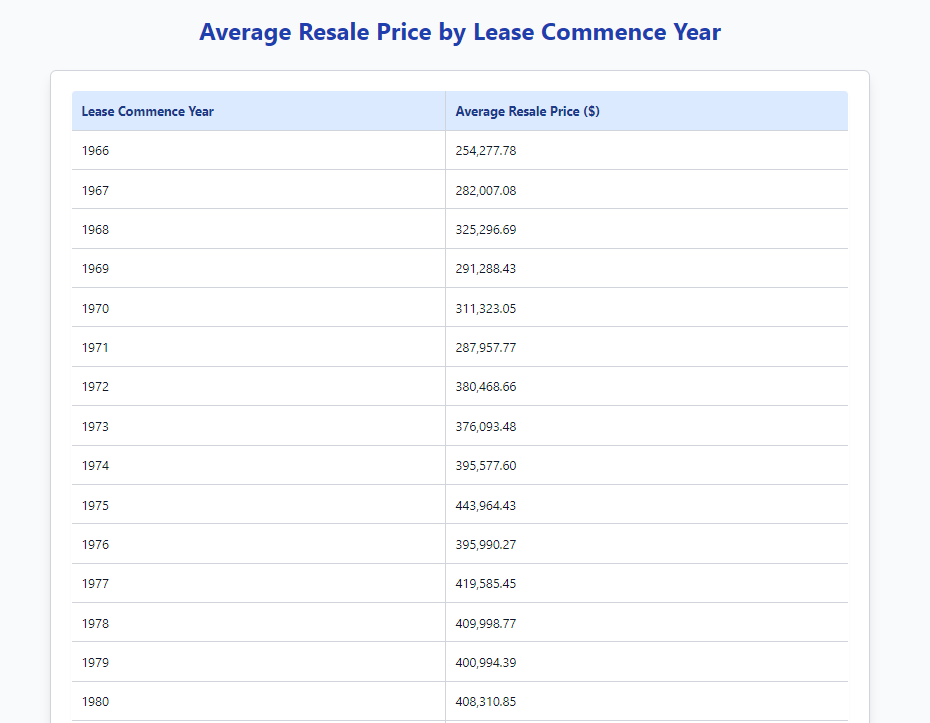

This section of the web application explores how average resale prices differ across various storey ranges. To do this, we created the /avg-price-by-storey route and wrote a SQL query that groups the resale data by storey range. It calculates the average resale price for each group using the AVG() function and formats the result to two decimal places for clarity.

The query joins the Flat and Transaction tables through the flat_id, and then groups all flats based on their storey_range. Finally, the results are sorted by the storey range to ensure that the values appear in a logical, ascending order.

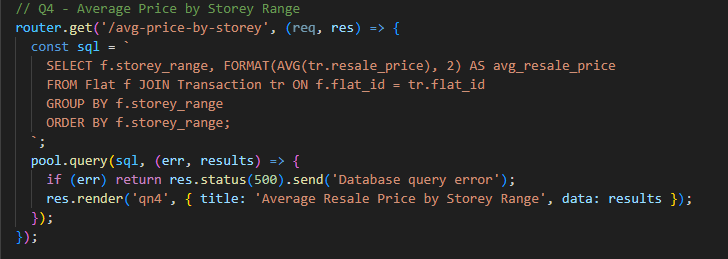

Once the data is retrieved from the database, it’s passed to the qn4.ejs file. On the front end, the table clearly shows each storey range alongside its corresponding average resale price. This makes it easy for users to spot trends, such as how flats located on higher floors tend to have higher average resale values. 

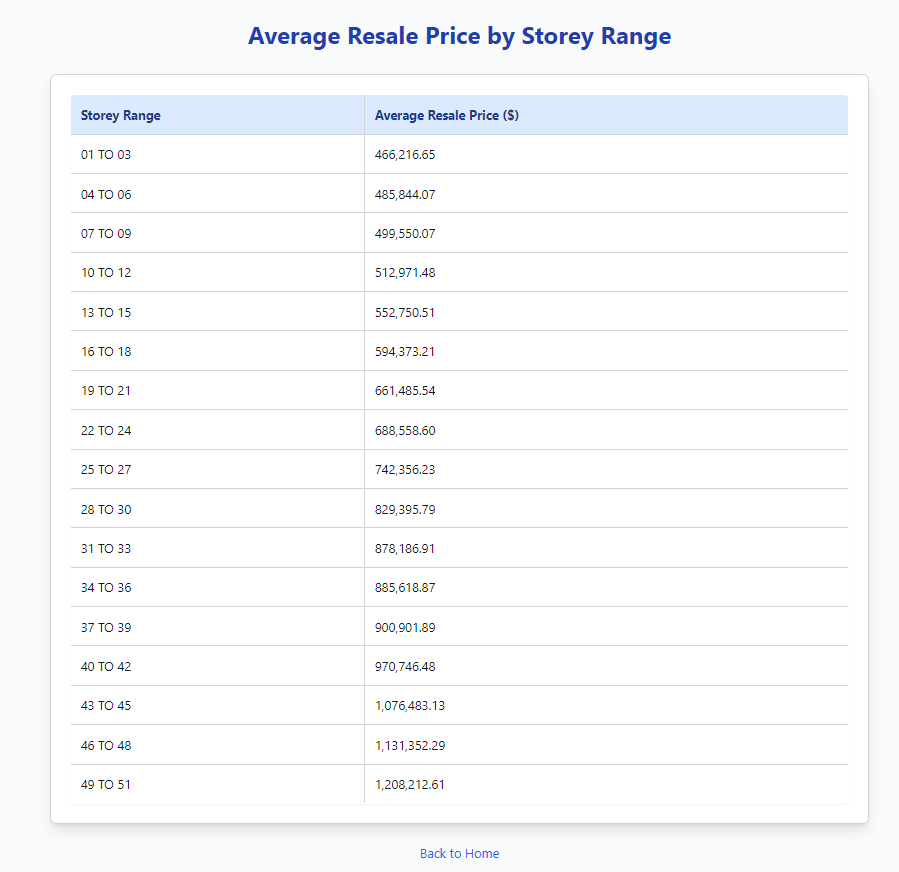

This part of the application helps users explore how many resale transactions took place in each town, grouped by flat type. In the backend, we set up a route called /transactions-by-town. Inside this route, we created a SQL query that pulls together data from several tables: Town, Block, Flat, and Transaction.

The query connects these tables using their related fields and groups the results by both town name and flat type. It then counts the number of transactions in each group using the COUNT(*) function. The results are sorted so that towns with more resale activity appear first.

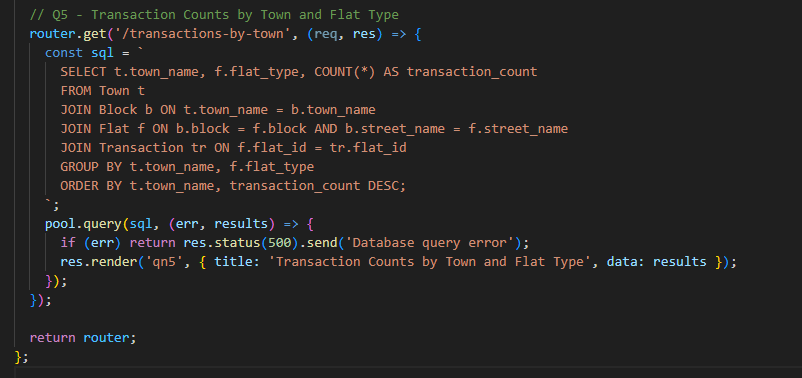

Once the data is ready, it is passed into the qn5.ejs file, where it is shown in a clean and easy-to-read table. At the top of the page, users can select a town from a list of buttons. After choosing a town, they will see the number of resale transactions for each flat type in that area.

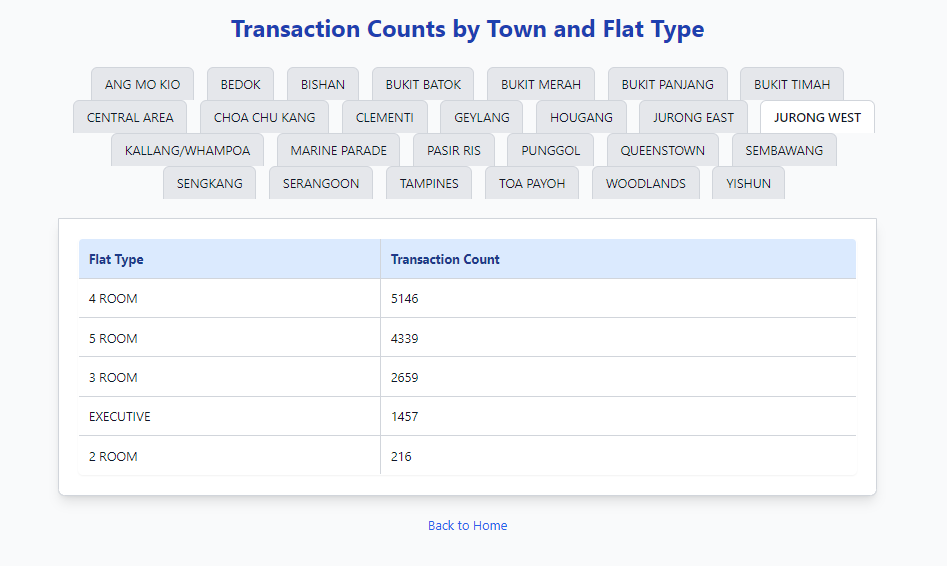


### References

[1] Elmasri, R., & Navathe, S. B. (2016). *Fundamentals of Database Systems* (7th ed.). Pearson Education. A widely recognized text covering principles of database modeling, E/R diagrams, and relational schema mapping.

[2] Housing & Development Board (HDB). (n.d.). *Resale Flat Prices*. data.gov.sg. Retrieved from https://data.gov.sg/dataset/resale-flat-prices

[3] Connolly, T., & Begg, C. (2015). *Database Systems: A Practical Approach to Design, Implementation, and Management* (6th ed.). Pearson Education. This book covers advanced topics in normalization including BCNF and database scalability.

[4] Elmasri, R., & Navathe, S. B. (2016). Fundamentals of Database Systems (7th ed.). Pearson.

[5] Coronel, C., & Morris, S. (2015). Database Systems: Design, Implementation, & Management (11th ed.). Cengage Learning.

[6] Date, C. J. (2003). An Introduction to Database Systems (8th ed.). Addison-Wesley.

[7] GeeksforGeeks. (n.d.). Database Normalization Basics. Retrieved from https://www.geeksforgeeks.org/database-normalization/

[8] Express.js, Express - Node.js web application framework. [Online]. Available: https://expressjs.com

[9] MySQL, MySQL 8.0 Reference Manual - MySQL User Account Management. [Online]. Available: https://dev.mysql.com/doc/refman/8.0/en/user-account-management.html
